<a href="https://colab.research.google.com/github/Riz2693/Eksperimen-TensorFlow/blob/main/Sistem_Rekomendasi_Lanjutan_Dengan_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Muhammad Faris Akbar**

## **Neural Collaborative Filtering**

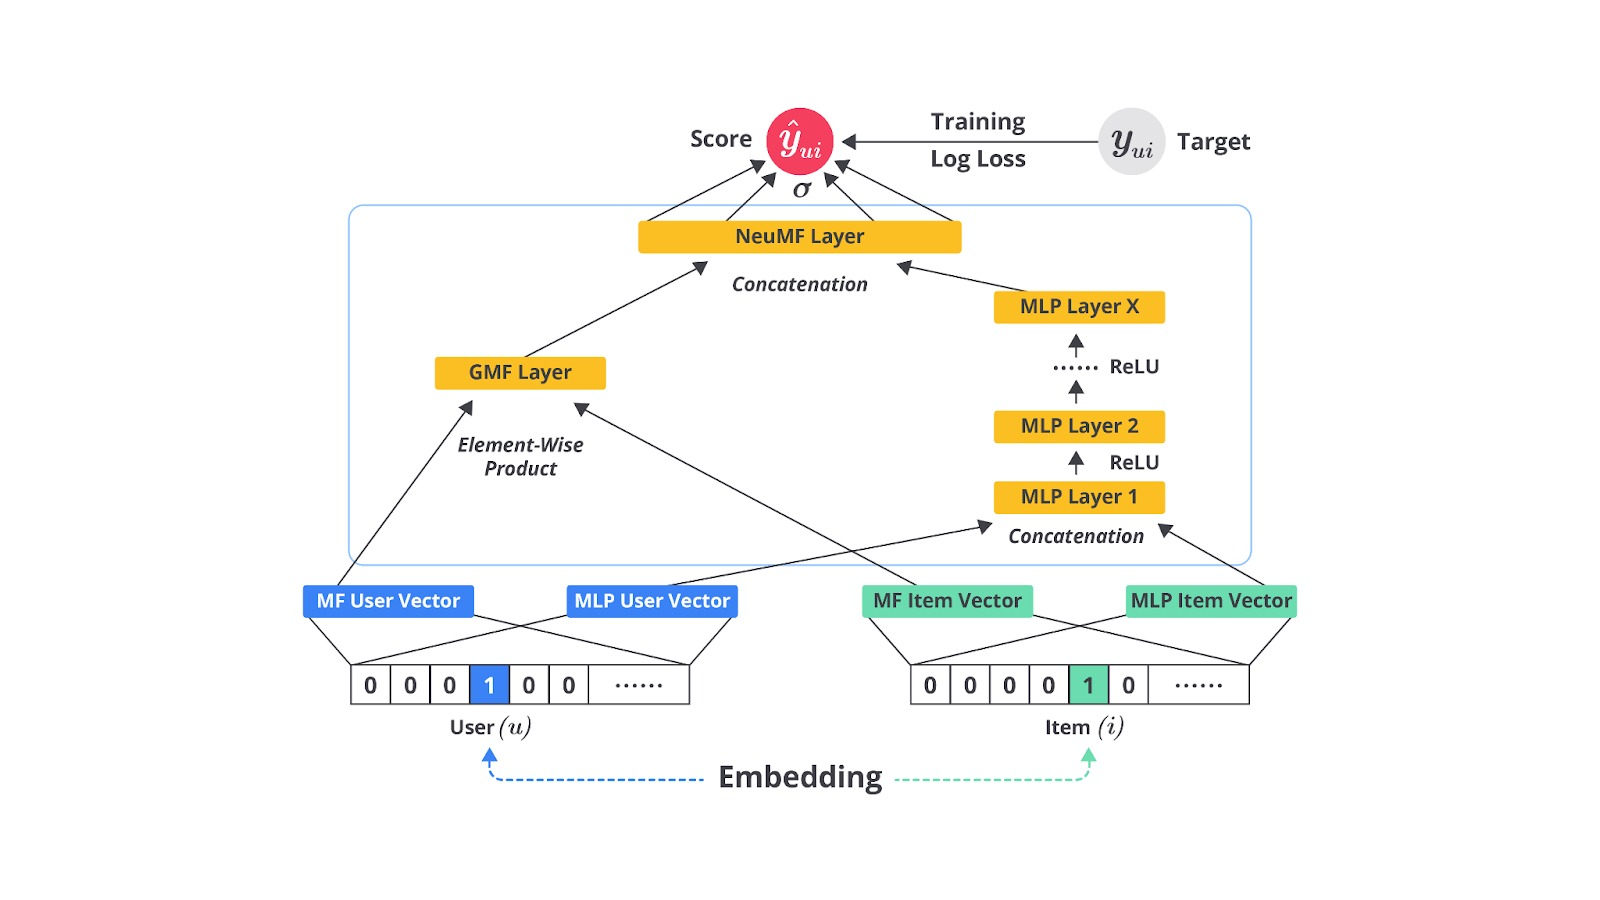

**Tahapan Neural Collaborative Filtering**

1. Embedding: Pengubahan representasi data diskrit menjadi vektor
2. Generalized Matrix Factorization: Perkalian matriks based on element-wise product

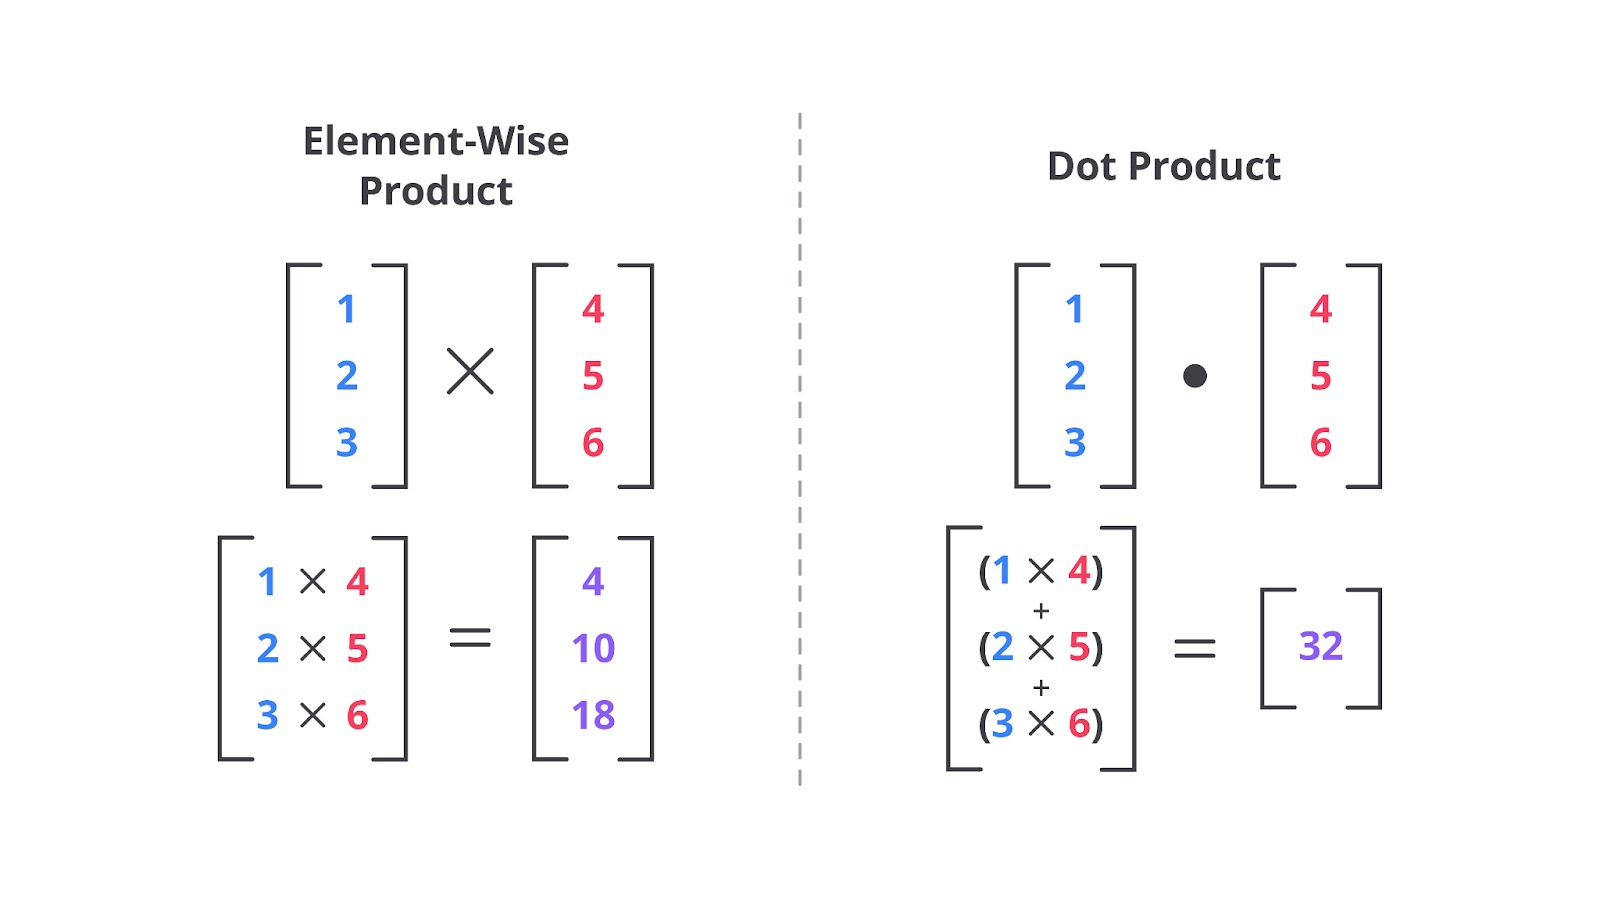

3. Multi-Layer Perceptron (MLP): Penganganan hubungan non-linier antara user dan item
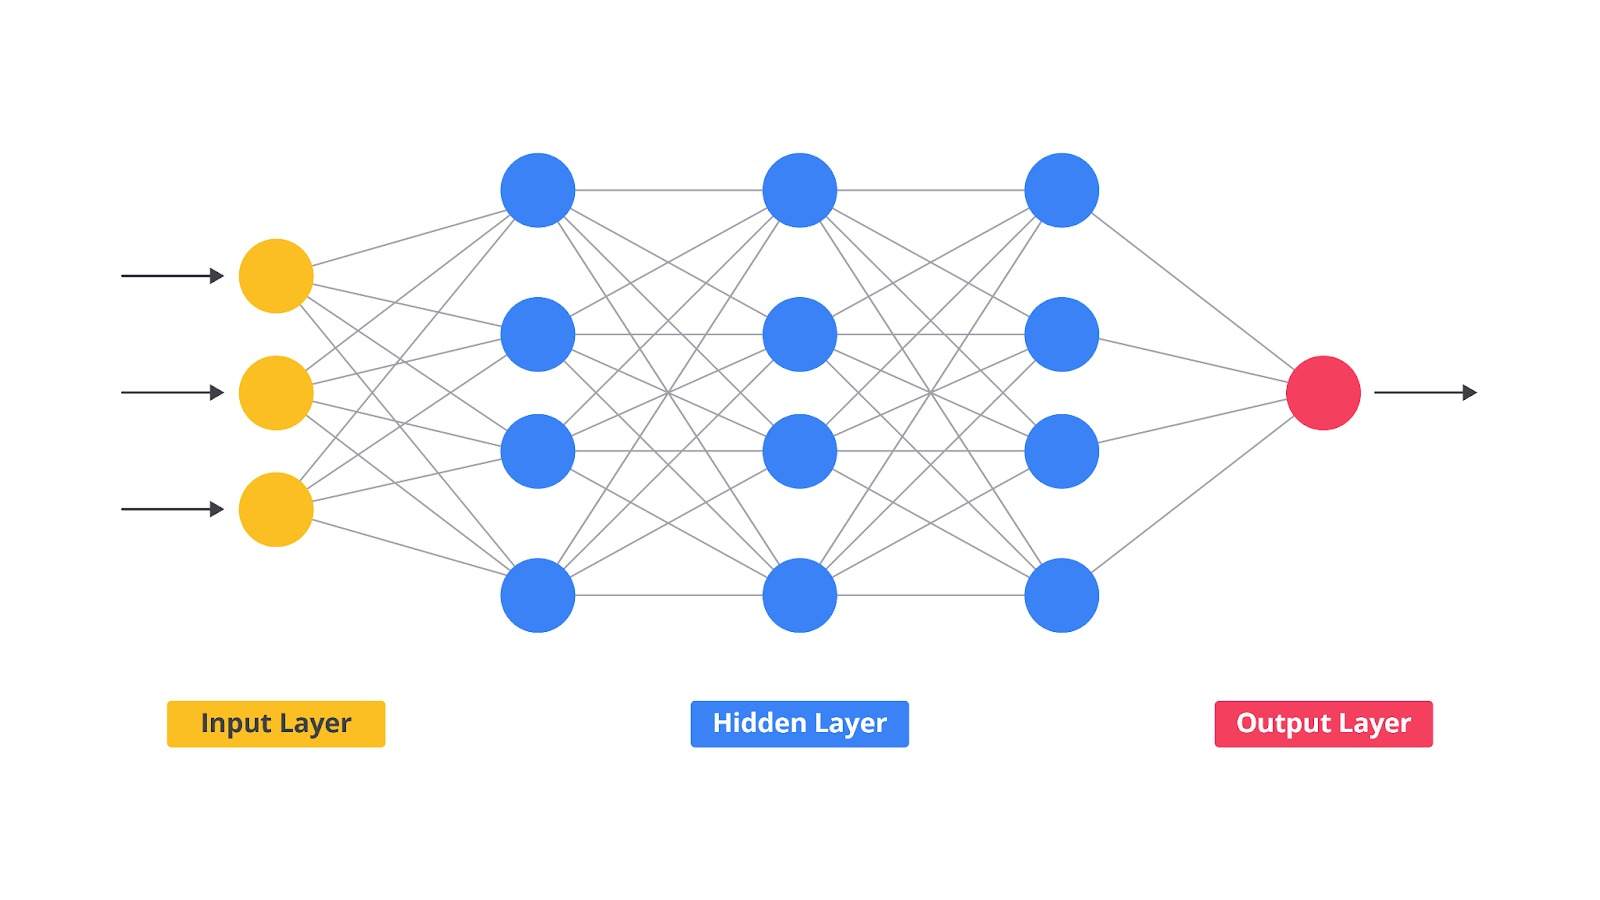

4. Neural Matrix Factorization (NeuMF): 2 output penting dari komponen Generalized Matrix Factorization (GMF) dan Multi-Layer Perceptron (MLP) akan digabungkan menggunakan sebuah Concatenation Layer.

## **Context-Aware Recommendations**

## **Hybrid Recommender System**

In [3]:
!pip install tensorflow_recommenders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 4.9 MB/s eta 0:00:00


In [4]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [5]:
import pandas as pd
import numpy as np
import kagglehub
import tensorflow as tf
import tensorflow_recommenders as tfrs
from tensorflow.keras.metrics import MeanSquaredError
from sklearn.preprocessing import (
    MultiLabelBinarizer,
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [ ]:
path = kagglehub.dataset_download("CooperUnion/anime-recommendations-database")

print("Path to dataset files: ", path)

In [ ]:
df_content = pd.read_csv(f"{path}/anime.csv")
df_rating = pd.read_csv(f"{path}/rating.csv")

In [ ]:
df_content.head(5)

In [ ]:
df_rating.head(5)

In [ ]:
rating_counts = df_rating['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
rating_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi Rating Sebelum Pembersihan")
plt.xlabel("Rating")
plt.xticks(rotation=0)
plt.ylabel("Jumlah Pengguna")
plt.show()

In [ ]:
df_rating_cleaned = df_rating[df_rating['rating'] != -1]
rating_cleaned_count = df_rating_cleaned['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
rating_cleaned_count.plot(kind='bar', color='skyblue')
plt.title("Distribusi Rating Setelah Pembersihan")
plt.xlabel("Rating")
plt.xticks(rotation=0)
plt.ylabel("Jumlah Pengguna")
plt.show()

In [ ]:
mlb_genre = MultiLabelBinarizer()

In [ ]:
df_content['genre'] = df_content['genre'].astype(str).fillna("")
df_content['genre_list'] = df_content['genre'].str.split(', ')
X_genre = mlb_genre.fit_transform(df_content['genre_list'])

X_genre

In [ ]:
enc_type = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_type = enc_type.fit_transform(df_content[['type']])

X_type

In [ ]:
num_cols = ['episodes', 'rating', 'members']
scaler = StandardScaler()

In [ ]:
for num in num_cols:
  df_content[num] = pd.to_numeric(df_content[num], errors='coerce').fillna(0)
X_num = scaler.fit_transform(df_content[num_cols].fillna(0))

X_num

In [ ]:
content_features = np.hstack([X_genre, X_type, X_num])
content_features /= np.linalg.norm(content_features, axis=1, keepdims=True)

content_features

In [ ]:
encode_user = LabelEncoder()
encode_item = LabelEncoder()

df_rating_cleaned['user_idx'] = encode_user.fit_transform(df_rating_cleaned['user_id'])
df_rating_cleaned['item_idx'] = encode_item.fit_transform(df_rating_cleaned['anime_id'])

num_users = df_rating_cleaned['user_idx'].nunique()
num_items = df_rating_cleaned['item_idx'].nunique()

In [ ]:
df_train, df_val = train_test_split(df_rating_cleaned, test_size=0.2, random_state=42)

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((
    {
        'user_id': df_train['user_idx'].values,
        'item_id': df_train['item_idx'].values
    },
    df_train['rating'].astype('float32').values
))

val_ds = tf.data.Dataset.from_tensor_slices((
    {
        'user_id': df_val['user_idx'].values,
        'item_id': df_val['item_idx'].values
    },
    df_val['rating'].astype('float32').values
))

train_ds = train_ds.shuffle(1000000).batch(512).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(512).prefetch(tf.data.AUTOTUNE)

**Komponen Utama NCF**
1. GMF (Generalized Matrix Factorization): Menghitung interaksi linier antara embedding pengguna dan item menggunakan Matrix Factorization yang digeneralisasi.
2. MLP (Multi-Layer Perceptron): Mempelajari interaksi non-linier melalui lapisan fully connected.
3. NeuMF (Neural Matrix Factorization): Menggabungkan output dari GMF dan MLP, lalu memproyeksikannya ke dalam satu lapisan prediksi akhir.

In [ ]:
def build_inputs():
  u_in = tf.keras.Input(shape=(), name='user_id', dtype='int32')
  i_in = tf.keras.Input(shape=(), name='item_id', dtype='int32')

  return u_in, i_in

In [ ]:
# GMF (Generalized Matrix Factorization) branch
def build_gmf_branch(u_in, i_in, num_users, num_items, emb_dim):
  u_g = tf.keras.layers.Embedding(num_users, emb_dim, name='gmf_user_emb')(u_in)
  i_g = tf.keras.layers.Embedding(num_items, emb_dim, name='gmf_item_emb')(i_in)
  u_g = tf.keras.layers.Flatten()(u_g)
  i_g = tf.keras.layers.Flatten()(i_g)
  gmf_out = tf.keras.layers.Multiply()([u_g, i_g]) # elemnt-wise product

  return gmf_out

In [ ]:
# MLP branch
def build_mlp_branch(u_in, i_in, num_users, num_items, emb_dim):
    u_m = tf.keras.layers.Embedding(num_users, emb_dim, name='mlp_user_emb')(u_in)
    i_m = tf.keras.layers.Embedding(num_items, emb_dim, name='mlp_item_emb')(i_in)
    u_m = tf.keras.layers.Flatten()(u_m)
    i_m = tf.keras.layers.Flatten()(i_m)
    mlp_out = tf.keras.layers.Concatenate()([u_m, i_m])
    mlp_out = tf.keras.layers.Dense(64, activation='relu')(mlp_out)
    mlp_out = tf.keras.layers.Dropout(0.3)(mlp_out)
    mlp_out = tf.keras.layers.Dense(32, activation='relu')(mlp_out)

    return mlp_out

In [ ]:
# Gabungkan GMF + MLP menjadi NeuMF
def build_ncf(num_users, num_items, emb_dim=64):
    u_in, i_in = build_inputs()

    gmf_out = build_gmf_branch(u_in, i_in, num_users, num_items, emb_dim)
    mlp_out = build_mlp_branch(u_in, i_in, num_users, num_items, emb_dim)

    fusion = tf.keras.layers.Concatenate()([gmf_out, mlp_out])
    output = tf.keras.layers.Dense(1, activation='linear', name='prediction')(fusion)

    model = tf.keras.Model(inputs=[u_in, i_in], outputs=output)
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
ncf_model = build_ncf(num_users, num_items, emb_dim=16)
ncf_model.summary()

In [ ]:
ncf_model.fit(train_ds, epochs=5, validation_data=val_ds, verbose=1)

In [ ]:
# Ambil output dari kedua item embedding (GMF dan MLP)
item_input = ncf_model.input[1]  # i_in

# Ambil embedding output
gmf_item_emb_layer = ncf_model.get_layer('gmf_item_emb')
mlp_item_emb_layer = ncf_model.get_layer('mlp_item_emb')

gmf_item_emb = tf.keras.layers.Flatten()(gmf_item_emb_layer(item_input))
mlp_item_emb = tf.keras.layers.Flatten()(mlp_item_emb_layer(item_input))

# Gabungkan keduanya untuk feature augmentation
combined_item_emb = tf.keras.layers.Concatenate()([gmf_item_emb, mlp_item_emb])

In [ ]:
# Buat model ekstraksi embedding
emb_model = tf.keras.Model(inputs=item_input, outputs=combined_item_emb)

# Ekstraksi embedding untuk semua item
all_items = np.arange(num_items, dtype=np.int32)
item_embs = emb_model.predict(all_items, batch_size=512)
item_embs = item_embs.squeeze()

# Normalize item embeddings
item_embs /= np.linalg.norm(item_embs, axis=1, keepdims=True)

In [ ]:
# Feature Augmentation
# Cari data anime yang ada di kedua sumber (content + CF)
common_mask = df_content['anime_id'].isin(encode_item.classes_)
filtered_idx = np.where(common_mask.values)[0]

# Ambil indeks sesuai versi CF dan cocokkan dengan fitur konten
cf_indices = encode_item.transform(df_content.loc[common_mask, 'anime_id'])
content_f = content_features[filtered_idx]
cf_f = item_embs[cf_indices]

# Gabungkan kedua jenis fitur jadi satu representasi
aug_features = np.hstack([content_f, cf_f])

# Normalisasi supaya setiap vektor punya panjang yang sama
aug_features /= np.linalg.norm(aug_features, axis=1, keepdims=True)

In [ ]:
# Perhitungan similarity
sim_aug = cosine_similarity(aug_features)
idx_meta = df_content.loc[common_mask].reset_index(drop=True)

# Fungsi inference rekomendasi
def recommend(anime_id, top_n=10):
    idx = idx_meta.index[idx_meta['anime_id'] == anime_id][0]
    sims = sim_aug[idx]
    order = np.argsort(sims)[::-1]
    order = order[order != idx]
    top = order[:top_n]
    return [(int(idx_meta.iloc[i]['anime_id']), idx_meta.iloc[i]['name'], float(sims[i]))
            for i in top]

In [ ]:
# Contoh
eid = df_content['anime_id'].iloc[1]
idx = df_content.index[df_content['anime_id'] == eid][0]
name_anime = df_content['name'].iloc[idx]

print('NCF-augmented Recommendations untuk', name_anime, f"({eid})")
for mid, name, score in recommend(eid, 10):
    print(mid, name, f"{score:.4f}")

**Two Tower Retrieval dengan TFRS**

In [6]:
class Query_Tower(tf.keras.Model):
  def __init__(self, layer_size, vocab_dict) -> None:
     super().__init__()

     self.user_name_text_embedding = tf.keras.Sequential([
             tf.keras.layers.TextVectorization(
                 vocabulary=vocab_dict['user_name'],
                 ngrams = 2,
             ),
             tf.keras.layers.Embedding(
                 input_dim = len(vocab_dict['user_name']) + 1, # Ukuran vocab + OOV
                 output_dim = EMBEDDING_DIM
                 ),
             tf.keras.layers.GlobalAveragePooling1D(),
         ])

     self.gender_lookup = tf.keras.layers.StringLookup(
         vocabulary=vocab_dict['gender'],
         mask_token=None
     )

     self.gender_embedding = tf.keras.layers.Embedding(
         input_dim = len(vocab_dict['gender']) + 1,
         output_dim = 8
     )

     self.age_norm = tf.keras.layers.Normalization(axis=None)

     self.dnn = tf.keras.Sequential(name="query_dnn")
     for layer_size in layer_size[:-1]:
      self.dnn.add(tf.keras.layers.Dense(layer_size, activation="relu"))
     self.dnn.add(tf.keras.layers.Dense(layer_size[-1]))

  def call(self, data):
     user_name = self.user_name_text_embedding(data["user_name"])
     gender = self.gender_embedding(self.gender_lookup(data["gender"]))

     age = tf.reshape(self.age_norm(data["age"]), (-1, 1))

     all_emb = tf.concat([user_name, gender, age], axis=1)

     return self.dnn(all_emb)

In [7]:
class Candidat_Tower(tf.keras.Model):
  def __init__(self, layer_size, vocab_dict) -> None:
     super().__init__()

     self.track_name_embedding = tf.keras.Sequential([
         tf.keras.layers.TextVectorization(
             vocabulary=vocab_dict['track_name'],
             name="track_name_vectorizer"
         ),
         tf.keras.layers.Embedding(
             input_dim = MAX_TOKENS,
             output_dim = EMBEDDING_DIM,
             name="track_name_emb_layer"
         ),
         tf.keras.layers.GlobalAveragePooling1D(name="track_name_pooling"),
     ])

     self.dnn = tf.keras.Sequential(name="candidate_dnn")
     for layer_size in layer_size[:-1]:
      self.dnn.add(tf.keras.layers.Dense(layer_size, activation="relu"))
     self.dnn.add(tf.keras.layers.Dense(layer_size[-1]))

  def call(self, data):
    track_embedding = self.track_name_embedding(data["track_name_can"])
    return self.dnn(track_embedding)

In [8]:
class TheTwoTowers(tfrs.models.Model):
  def __init__(self, layer_size, vocab_dict, parsed_candidate_dataset):
    super().__init__()
    self.query_tower = Query_Tower(layer_size, vocab_dict)
    self.candidate_tower = Candidat_Tower(layer_size, vocab_dict)

    self.task = tfrs.tasks.Retrieval(
        metrics=tfrs.metrics.FactorizedTopK(
            candidates=parsed_candidate_dataset.batch(128).map(self.candidate_tower)
        )
    )

  def compute_loss(self, data, training=False):
    query_embedding = self.query_tower(data)
    candidate_embedding = self.candidate_tower(data)

    return self.task(
        query_embedding,
        candidate_embedding,
        compute_metrics = not training
    )